In [1]:
import pandas as pd

In [2]:
# dataframe
data = {'country': ['Belgium', 'France', 'Germany', 'Netherlands', 'United Kingdom'],
        'population': [11.3, 64.3, 81.3, 16.9, 64.9],
        'area': [30510, 671308, 357050, 41526, 244820],
        'capital': ['Brussels', 'Paris', 'Berlin', 'Amsterdam', 'London']}
countries = pd.DataFrame(data)
countries = countries.set_index('country') # 인덱스 지정
countries

,population,area,capital
country,,,
Belgium,11.3,30510,Brussels
France,64.3,671308,Paris
Germany,81.3,357050,Berlin
Netherlands,16.9,41526,Amsterdam
United Kingdom,64.9,244820,London


---

<div class="alert alert-success">
    <b>EXERCISE</b>: 인구밀도를 의미하는 `density` 칼럼을 추가하세요. (주의: 현재 'population' 칼럼은 100만 단위로 표기되어 있습니다)  
  
</div>

In [13]:
countries.head()

,population,area,capital
country,,,
Belgium,11.3,30510,Brussels
France,64.3,671308,Paris
Germany,81.3,357050,Berlin
Netherlands,16.9,41526,Amsterdam
United Kingdom,64.9,244820,London


In [90]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, Belgium to United Kingdom
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   population  5 non-null      float64
 1   area        5 non-null      int64  
 2   capital     5 non-null      object 
 3   density     5 non-null      float64
dtypes: float64(2), int64(1), object(1)
memory usage: 372.0+ bytes


In [14]:
countries.describe()

,population,area
count,5.000000,5.000000
mean,47.740000,269042.800000
std,31.519645,264012.827994
min,11.300000,30510.000000
25%,16.900000,41526.000000
50%,64.300000,244820.000000
75%,64.900000,357050.000000
max,81.300000,671308.000000


In [16]:
countries['density'] = countries.apply(lambda x: x['population']*1000000 / x['area'], axis=1)
countries

,population,area,capital,density
country,,,,
Belgium,11.3,30510,Brussels,370.370370
France,64.3,671308,Paris,95.783158
Germany,81.3,357050,Berlin,227.699202
Netherlands,16.9,41526,Amsterdam,406.973944
United Kingdom,64.9,244820,London,265.092721


<div class="alert alert-success">
    <b>EXERCISE</b>: 인구밀도가 300을 초과하는 국가(country)의 수도(capital)과 인구(population)을 선택해주세요.  
  
</div>

In [19]:
countries.loc[countries['density'] > 300, ['capital', 'population']]

,capital,population
country,,
Belgium,Brussels,11.3
Netherlands,Amsterdam,16.9


<div class="alert alert-success">
    <b>EXERCISE</b>: 'density_ratio' 칼럼을 추가해주세요. (density_ratio = 인구밀도/평균 인구밀도)
</div>

In [87]:
countries.describe()

,population,area,density
count,5.000000,5.000000,5.000000
mean,47.740000,269042.800000,273.183879
std,31.519645,264012.827994,123.440607
min,11.300000,30510.000000,95.783158
25%,16.900000,41526.000000,227.699202
50%,64.300000,244820.000000,265.092721
75%,64.900000,357050.000000,370.370370
max,81.300000,671308.000000,406.973944


In [93]:
countries['density_ratio'] = countries['density'] / countries['density'].mean()
countries

,population,area,capital,density,density_ratio
country,,,,,
Belgium,11.3,30510,Brussels,370.370370,1.355755
France,64.3,671308,Paris,95.783158,0.350618
Germany,81.3,357050,Berlin,227.699202,0.833502
Netherlands,16.9,41526,Amsterdam,406.973944,1.489744
United Kingdom,64.9,244820,London,265.092721,0.970382


<div class="alert alert-success">
    <b>EXERCISE</b>: 영국(United Kingdom)의 수도(capital)를 'Cambridge'로 변경해주세요.
</div>

In [94]:
countries.loc['United Kingdom', 'capital'] = 'Cambridge'
countries

,population,area,capital,density,density_ratio
country,,,,,
Belgium,11.3,30510,Brussels,370.370370,1.355755
France,64.3,671308,Paris,95.783158,0.350618
Germany,81.3,357050,Berlin,227.699202,0.833502
Netherlands,16.9,41526,Amsterdam,406.973944,1.489744
United Kingdom,64.9,244820,Cambridge,265.092721,0.970382


<div class="alert alert-success">
    <b>EXERCISE</b>: 인구 밀도가 100 초과, 300 미만인 국가들을 표시해주세요.  
</div>

In [23]:
countries[(countries['density'] > 100) & (countries['density'] < 300)]

,population,area,capital,density
country,,,,
Germany,81.3,357050,Berlin,227.699202
United Kingdom,64.9,244820,London,265.092721


<div class="alert alert-success">
    <b>EXERCISE</b>: 수도가 7글자 이상인 국가들을 표시해주세요. (힌트: string의 len( )를 사용하세요.)
</div>

In [33]:
countries[countries['capital'].str.len() >= 7]

,population,area,capital,density
country,,,,
Belgium,11.3,30510,Brussels,370.370370
Netherlands,16.9,41526,Amsterdam,406.973944


<div class="alert alert-success">
    <b>EXERCISE</b>: 수도에 'am' 이 포함되는 국가들을 표시해주세요. (힌트: string의 contains( )를 사용하세요.)
</div>

In [34]:
countries[countries['capital'].str.contains('am')]

,population,area,capital,density
country,,,,
Netherlands,16.9,41526,Amsterdam,406.973944


# 영화리뷰 데이터에서 자료 찾기

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [45]:
df = pd.read_csv('./data/movie_title_data.tsv', sep="\t")
df

C:\Users\5-25\AppData\Local\Temp\ipykernel_3832\2737272239.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/movie_title_data.tsv', sep="\t")


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Pauvre Pierrot,Pauvre Pierrot,0,1892,\N,4,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,"Comedy,Short"
...,...,...,...,...,...,...,...,...,...
8407394,tt9916848,tvEpisode,Episode #3.17,Episode #3.17,0,2010,\N,\N,"Action,Drama,Family"
8407395,tt9916850,tvEpisode,Episode #3.19,Episode #3.19,0,2010,\N,\N,"Action,Drama,Family"
8407396,tt9916852,tvEpisode,Episode #3.20,Episode #3.20,0,2010,\N,\N,"Action,Drama,Family"
8407397,tt9916856,short,The Wind,The Wind,0,2015,\N,27,Short


<div class="alert alert-success">
    <b>EXERCISE</b>: titles 데이터프레임에는 몇 개의 영화가 기록되어 있나요?
</div>

In [46]:
df.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Pauvre Pierrot,Pauvre Pierrot,0,1892,\N,4,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,"Comedy,Short"


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8407399 entries, 0 to 8407398
Data columns (total 9 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   tconst          object
 1   titleType       object
 2   primaryTitle    object
 3   originalTitle   object
 4   isAdult         object
 5   startYear       object
 6   endYear         object
 7   runtimeMinutes  object
 8   genres          object
dtypes: object(9)
memory usage: 577.3+ MB


In [55]:
df['primaryTitle'].nunique()

4000746

<div class="alert alert-success">
    <b>EXERCISE</b>: titles에서 가장 빠른 시기에 제작된 영화 두 개를 표시하세요.  힌트: .sort_values()
</div>

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8407399 entries, 0 to 8407398
Data columns (total 9 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   tconst          object
 1   titleType       object
 2   primaryTitle    object
 3   originalTitle   object
 4   isAdult         object
 5   startYear       object
 6   endYear         object
 7   runtimeMinutes  object
 8   genres          object
dtypes: object(9)
memory usage: 577.3+ MB


In [97]:
df['startYear'] = df['startYear'].apply(int)

ValueError: invalid literal for int() with base 10: '\\N'

In [98]:
df = df[df['startYear'] != '\\N']

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7384286 entries, 0 to 8407398
Data columns (total 9 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   tconst          object
 1   titleType       object
 2   primaryTitle    object
 3   originalTitle   object
 4   isAdult         object
 5   startYear       object
 6   endYear         object
 7   runtimeMinutes  object
 8   genres          object
dtypes: object(9)
memory usage: 563.4+ MB


In [101]:
df['startYear'] = df['startYear'].apply(int)

C:\Users\5-25\AppData\Local\Temp\ipykernel_3832\2061835706.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['startYear'] = df['startYear'].apply(int)


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7384286 entries, 0 to 8407398
Data columns (total 9 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   tconst          object
 1   titleType       object
 2   primaryTitle    object
 3   originalTitle   object
 4   isAdult         object
 5   startYear       int64 
 6   endYear         object
 7   runtimeMinutes  object
 8   genres          object
dtypes: int64(1), object(8)
memory usage: 563.4+ MB


In [103]:
df['startYear'].sort_values()

5329521    1874
3488807    1877
4855464    1878
2431429    1878
3946861    1881
           ... 
2619250    2027
1898834    2027
2144979    2028
6427631    2028
3158370    2028
Name: startYear, Length: 7384286, dtype: int64

In [104]:
df.sort_values(by='startYear').iloc[:2, :]

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
5329521,tt3155794,short,Passage de Venus,Passage de Venus,0,1874,\N,1,"Documentary,Short"
3488807,tt14495706,short,La Rosace Magique,La Rosace Magique,0,1877,\N,1,"Animation,Short"


<div class="alert alert-success">
    <b>EXERCISE</b>: 제목(title)이 "Hamlet"인 영화는 몇 개가 있나요?
</div>

In [71]:
df[df['primaryTitle'] == "Hamlet"]

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
625,tt0000630,movie,Hamlet,Amleto,0,1908,\N,\N,Drama
626,tt0000631,short,Hamlet,Amleto,0,1908,\N,\N,"Drama,Short"
1228,tt0001240,movie,Hamlet,Hamlet,0,1911,\N,\N,Drama
1229,tt0001241,short,Hamlet,Hamlet,0,1910,\N,20,"Drama,Short"
1230,tt0001242,short,Hamlet,Hamlet,0,1908,\N,\N,"Drama,Short"
...,...,...,...,...,...,...,...,...,...
7347169,tt7656792,tvEpisode,Hamlet,Hamlet,0,2017,\N,\N,Animation
7413345,tt7798632,movie,Hamlet,Hamlet,0,\N,\N,\N,Comedy
7476376,tt7934018,tvMovie,Hamlet,Hamlet,0,1983,\N,\N,Drama
7609545,tt8219328,tvMovie,Hamlet,Hamlet,0,2018,\N,191,Drama


<div class="alert alert-success">
    <b>EXERCISE</b>: 제목(title)이 "Treasure Island"인 영화를 제작년도(year)의 오름차순에 따라 표시하세요
</div>

In [61]:
df[(df['primaryTitle'] == "Treasure Island").sort_values()]

C:\Users\5-25\AppData\Local\Temp\ipykernel_3832\132902004.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[(df['primaryTitle'] == "Treasure Island").sort_values()]


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
2511,tt0002538,short,Treasure Island,Treasure Island,0,1912,\N,\N,"Adventure,Short"
9589,tt0009721,movie,Treasure Island,Treasure Island,0,1917,\N,60,Adventure
11620,tt0011785,movie,Treasure Island,Treasure Island,0,1920,\N,76,Adventure
25459,tt0025907,movie,Treasure Island,Treasure Island,0,1934,\N,110,"Adventure,Family"
42318,tt0043067,movie,Treasure Island,Treasure Island,0,1950,\N,96,"Adventure,Family"
...,...,...,...,...,...,...,...,...,...
7532687,tt8054698,videoGame,Treasure Island,Treasure Island,0,1985,\N,\N,Adventure
7709443,tt8431946,tvEpisode,Treasure Island,Treasure Island,0,2018,\N,83,"Comedy,Reality-TV"
7720770,tt8455816,movie,Treasure Island,L'île au trésor,0,2018,\N,97,Documentary
7838572,tt8709864,tvSeries,Treasure Island,Treasure Island,0,\N,\N,\N,Reality-TV


<div class="alert alert-success">
    <b>EXERCISE</b>: 1950년에서 1959년 사이 몇 개의 영화가 만들어졌나요?(1950 <= 제작년도 <= 1959)
</div>

In [108]:
df.loc[(df['startYear'] >= 1950) & (df['startYear'] <= 1959), 'primaryTitle'].nunique()

84476

# 타이타닉 자료에서 그룹별 연산하기

In [38]:
titanic = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/Taitanic_train.csv")

In [39]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


<div class="alert alert-success">
    <b>EXERCISE</b>: groupby()를 사용하여 각 성별(sex)의 평균 나이(age)를 구하세요.
</div>

In [109]:
titanic.groupby('Sex')[['Age']].mean()

,Age
Sex,
female,27.915709
male,30.726645


<div class="alert alert-success">
    <b>EXERCISE</b>: 전체 승객(passenger)의 평균 생존율을 구하세요.
</div>

In [110]:
len(titanic[titanic['Survived'] == 1]) / len(titanic) * 100

38.38383838383838

<div class="alert alert-success">
    <b>EXERCISE</b>: 25세 이하 승객의 생존율을 구하세요. (힌트: 불리언 인덱싱)
</div>

In [111]:
len(titanic[(titanic['Age'] <= 25) & (titanic['Survived'] == 1)]) / len(titanic[titanic['Age'] <= 25]) * 100

41.19601328903654

<div class="alert alert-success">
    <b>EXERCISE</b>: 남성의 생존율을 구하세요. 여성의 생존율을 구하세요. (힌트: 불리언 인덱싱)
</div>

In [112]:
len(titanic[(titanic['Sex'] == 'male') & (titanic['Survived'] == 1)]) / len(titanic[titanic['Sex'] == 'male']) * 100

18.890814558058924

In [113]:
len(titanic[(titanic['Sex'] == 'female') & (titanic['Survived'] == 1)]) / len(titanic[titanic['Sex'] == 'female']) * 100

74.20382165605095

<div class="alert alert-success">
    <b>EXERCISE</b>: 생존율을 구하는 함수가 작성되어 있습니다. 성별 생존율을 groupby를 활용해 구하기 위해 ?부분을 알맞게 채워주세요.
</div>

In [114]:
def survival_ratio(survived):
    return survived.sum() / len(survived)

In [115]:
titanic.groupby('Sex')['Survived'].aggregate(survival_ratio)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [116]:
titanic.groupby('Sex')['Survived'].agg(['min', 'max', 'mean', 'median', 'describe'])

min      max      mean   median describe                           \
       Survived Survived  Survived Survived    count      mean       std  min   
Sex                                                                             
female        0        1  0.742038      1.0    314.0  0.742038  0.438211  0.0   
male          0        1  0.188908      0.0    577.0  0.188908  0.391775  0.0   

                            
        25%  50%  75%  max  
Sex                         
female  0.0  1.0  1.0  1.0  
male    0.0  0.0  0.0  1.0

<div class="alert alert-success">
    <b>EXERCISE</b>: 'Pclass'별로 생존율을 보기 위해 bar 차트를 그리고자 합니다. ?부분을 알맞게 채워서 bar 차트를 그려주세요.
</div>

<Axes: xlabel='Pclass'>

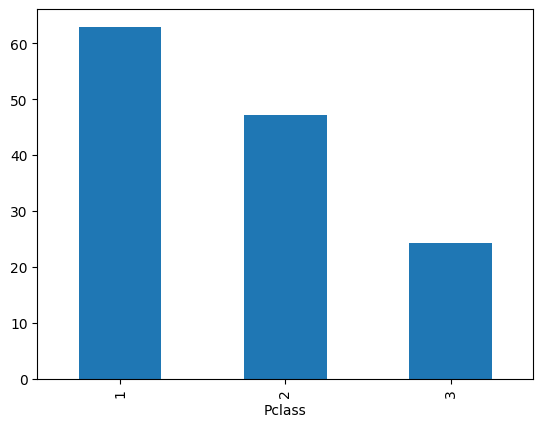

In [117]:
(titanic.groupby('Pclass')['Survived'].mean() * 100).plot(kind='bar')